<a href="https://colab.research.google.com/github/kazumah1/gait-decoding/blob/main/self_supervised_model_gait_decoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
DATA_PATH = '/content/drive/MyDrive/NTAB_Gait_Decoding_Project/Processed_New_Data/processed_csv/all_subjects_all_trials_merged.csv'

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape: (3240214, 71)
Columns: ['ID', 'Subject', 'Trial', 'time', 'FP1', 'FP2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'TP9_EOG', 'TP10_EOG', 'FT9_EOG', 'FT10_EOG', 'hip_right_angle', 'knee_right_angle', 'ankle_right_angle']


In [29]:
# Config
ANGLE_TO_PREDICT = 'hip_right_angle'  # or 'knee_right_angle' or 'ankle_right_angle'

# Define which columns are NOT EEG data
non_eeg_cols = ['ID', 'Subject', 'Trial', 'time',
                'TP9_EOG', 'TP10_EOG', 'FT9_EOG', 'FT10_EOG',  # EOG channels
                'hip_right_angle', 'knee_right_angle', 'ankle_right_angle']  # Targets

# Get EEG channel names (everything else)
eeg_channels = [col for col in df.columns if col not in non_eeg_cols]
NUM_CHANNELS = len(eeg_channels)

print(f"Found {NUM_CHANNELS} EEG channels")
print(f"Predicting: {ANGLE_TO_PREDICT}")

Found 60 EEG channels
Predicting: hip_right_angle


In [30]:
def create_windows(df, window_size=512, stride=256, eeg_channels=None, angle_column='hip_right_angle'):
    X_windows = []
    y_labels = []

    for (subject, trial), group in df.groupby(['Subject', 'Trial']):
        eeg_data = group[eeg_channels].values
        angles = group[angle_column].values

        for start in range(0, len(group) - window_size, stride):
            end = start + window_size
            window = eeg_data[start:end].T
            label = angles[start + window_size // 2]
            X_windows.append(window)
            y_labels.append(label)

        print(f"  {subject}-{trial}: {len(range(0, len(group) - window_size, stride))} windows")

    return np.array(X_windows), np.array(y_labels)

X, y = create_windows(df, eeg_channels=eeg_channels, angle_column=ANGLE_TO_PREDICT)
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

  SL01-T01: 535 windows
  SL01-T02: 535 windows
  SL01-T03: 536 windows
  SL02-T01: 535 windows
  SL02-T02: 517 windows
  SL02-T03: 525 windows
  SL03-T01: 536 windows
  SL03-T02: 521 windows
  SL03-T03: 527 windows
  SL04-T01: 534 windows
  SL04-T02: 520 windows
  SL04-T03: 512 windows
  SL05-T01: 536 windows
  SL05-T02: 536 windows
  SL05-T03: 508 windows
  SL06-T01: 536 windows
  SL06-T02: 520 windows
  SL06-T03: 508 windows
  SL07-T01: 536 windows
  SL07-T02: 512 windows
  SL07-T03: 511 windows
  SL08-T01: 536 windows
  SL08-T02: 535 windows
  SL08-T03: 515 windows

X shape: (12622, 60, 512)
y shape: (12622,)


In [31]:
# Check for NaN
print(f"NaN in X: {np.isnan(X).sum()}")
print(f"NaN in y: {np.isnan(y).sum()}")

# Normalize
X_mean, X_std = X.mean(), X.std()
y_mean, y_std = y.mean(), y.std()

X_normalized = (X - X_mean) / X_std
y_normalized = (y - y_mean) / y_std

print(f"X normalized range: {X_normalized.min():.2f} to {X_normalized.max():.2f}")
print(f"y normalized range: {y_normalized.min():.2f} to {y_normalized.max():.2f}")

NaN in X: 0
NaN in y: 0
X normalized range: -6.29 to 5.70
y normalized range: -2.71 to 3.94


In [32]:
class Encoder(nn.Module):
    def __init__(self, input_channels, latent_dim=64):
        super().__init__()
        self.conv1 = nn.Conv1d(input_channels, 32, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(4)
        self.fc = nn.Linear(64 * 32, latent_dim)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.flatten(1)
        return self.fc(x)


class Decoder(nn.Module):
    def __init__(self, output_channels, latent_dim=64):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 32)
        self.upsample = nn.Upsample(scale_factor=4)
        self.conv1 = nn.Conv1d(64, 32, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(32, output_channels, kernel_size=5, padding=2)

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 64, 32)
        x = self.upsample(x)
        x = torch.relu(self.conv1(x))
        x = self.upsample(x)
        return self.conv2(x)


class Autoencoder(nn.Module):
    def __init__(self, num_channels, latent_dim=64):
        super().__init__()
        self.encoder = Encoder(num_channels, latent_dim)
        self.decoder = Decoder(num_channels, latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed, z


class AnglePredictor(nn.Module):
    def __init__(self, pretrained_encoder, latent_dim=64, freeze_encoder=False):
        super().__init__()
        self.encoder = pretrained_encoder
        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
        self.head = nn.Linear(latent_dim, 1)

    def forward(self, x):
        z = self.encoder(x)
        return self.head(z)

In [33]:
class UnlabeledEEGDataset(Dataset):
    def __init__(self, X):
        self.X = torch.FloatTensor(X)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]

class LabeledEEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [34]:
def train_autoencoder(model, dataloader, epochs=50, lr=1e-3):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses = []

    for epoch in range(epochs):
        total_loss = 0
        for x_batch in dataloader:
            x_batch = x_batch.to(device)
            reconstructed, z = model(x_batch)
            loss = criterion(reconstructed, x_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)
        if epoch % 5 == 0:
            print(f"Epoch {epoch}: Loss = {avg_loss:.4f}")

    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Autoencoder Training')
    plt.show()
    return model, losses


def train_predictor(model, dataloader, epochs=50, lr=1e-3):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses = []

    for epoch in range(epochs):
        total_loss = 0
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            predicted = model(x_batch)
            loss = criterion(predicted, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)
        if epoch % 5 == 0:
            print(f"Epoch {epoch}: Loss = {avg_loss:.4f}")

    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Predictor Training')
    plt.show()
    return model, losses

Training Autoencoder...
Epoch 0: Loss = 0.0671
Epoch 5: Loss = 0.0110
Epoch 10: Loss = 0.0061
Epoch 15: Loss = 0.0110
Epoch 20: Loss = 0.0043
Epoch 25: Loss = 0.0061
Epoch 30: Loss = 0.0031
Epoch 35: Loss = 0.0035
Epoch 40: Loss = 0.0039
Epoch 45: Loss = 0.0030


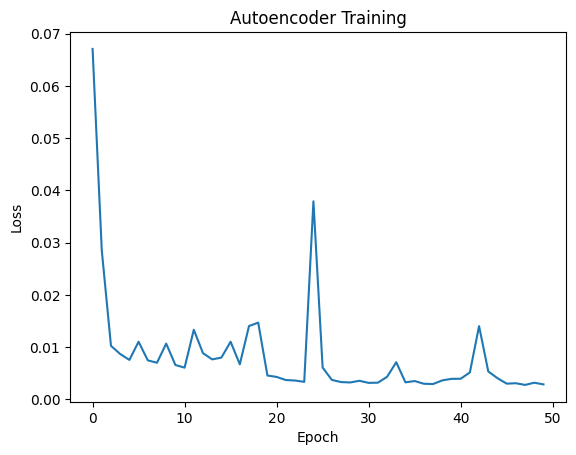

In [35]:
autoencoder = Autoencoder(num_channels=NUM_CHANNELS, latent_dim=64)
dataset_ae = UnlabeledEEGDataset(X_normalized)
dataloader_ae = DataLoader(dataset_ae, batch_size=64, shuffle=True)

print("Training Autoencoder...")
trained_autoencoder, ae_losses = train_autoencoder(autoencoder, dataloader_ae, epochs=50)

Training Predictor for hip_right_angle...
Epoch 0: Loss = 0.9921
Epoch 5: Loss = 0.8087
Epoch 10: Loss = 0.6956
Epoch 15: Loss = 0.6439
Epoch 20: Loss = 0.6359
Epoch 25: Loss = 0.6213
Epoch 30: Loss = 0.6379
Epoch 35: Loss = 0.5905
Epoch 40: Loss = 0.5585
Epoch 45: Loss = 0.5470


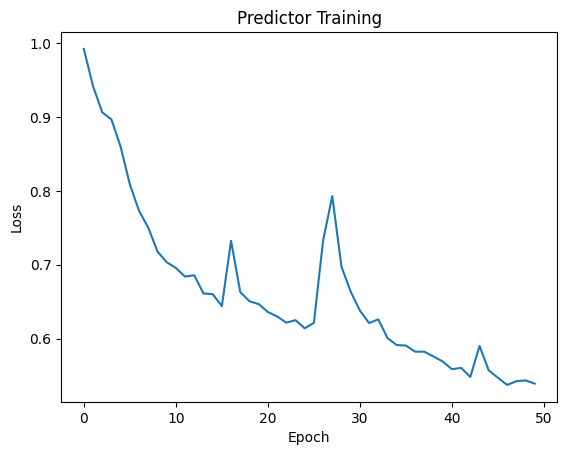

In [36]:
predictor = AnglePredictor(trained_autoencoder.encoder, latent_dim=64, freeze_encoder=False)
dataset_pred = LabeledEEGDataset(X_normalized, y_normalized)
dataloader_pred = DataLoader(dataset_pred, batch_size=64, shuffle=True)

print(f"Training Predictor for {ANGLE_TO_PREDICT}...")
trained_predictor, pred_losses = train_predictor(predictor, dataloader_pred, epochs=50)

Correlation: 0.695


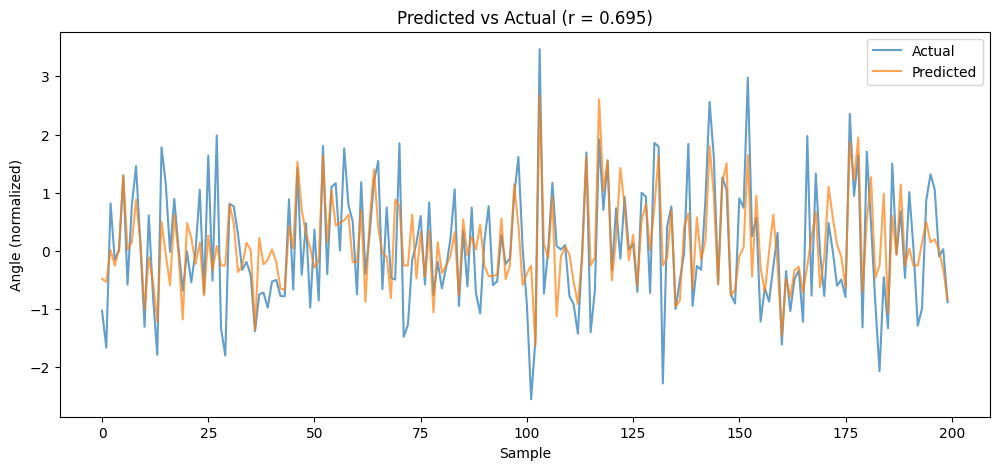

In [37]:
from scipy.stats import pearsonr

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
trained_predictor.eval()

all_preds = []
all_actual = []

with torch.no_grad():
    for x_batch, y_batch in dataloader_pred:
        x_batch = x_batch.to(device)
        preds = trained_predictor(x_batch).cpu().numpy()
        all_preds.extend(preds.flatten())
        all_actual.extend(y_batch.numpy().flatten())

correlation, _ = pearsonr(all_actual, all_preds)
print(f"Correlation: {correlation:.3f}")

plt.figure(figsize=(12, 5))
plt.plot(all_actual[:200], label='Actual', alpha=0.7)
plt.plot(all_preds[:200], label='Predicted', alpha=0.7)
plt.legend()
plt.title(f'Predicted vs Actual (r = {correlation:.3f})')
plt.xlabel('Sample')
plt.ylabel('Angle (normalized)')
plt.show()

In [38]:
print("=== DATA SUMMARY ===")
print(f"Total samples: {len(df):,}")
print(f"Subjects: {df['Subject'].unique()}")
print(f"Number of subjects: {df['Subject'].nunique()}")
print(f"Sessions per subject:")
for subj in df['Subject'].unique():
    sessions = df[df['Subject'] == subj]['Trial'].unique()
    print(f"  {subj}: {len(sessions)} sessions - {list(sessions)}")
print(f"\nEEG channels: {NUM_CHANNELS}")
print(f"Windows created: {len(X)}")
print(f"Predicting: {ANGLE_TO_PREDICT}")
print(f"Final correlation: 0.695")

=== DATA SUMMARY ===
Total samples: 3,240,214
Subjects: ['SL01' 'SL02' 'SL03' 'SL04' 'SL05' 'SL06' 'SL07' 'SL08']
Number of subjects: 8
Sessions per subject:
  SL01: 3 sessions - ['T01', 'T02', 'T03']
  SL02: 3 sessions - ['T01', 'T02', 'T03']
  SL03: 3 sessions - ['T01', 'T02', 'T03']
  SL04: 3 sessions - ['T01', 'T02', 'T03']
  SL05: 3 sessions - ['T01', 'T02', 'T03']
  SL06: 3 sessions - ['T01', 'T02', 'T03']
  SL07: 3 sessions - ['T01', 'T02', 'T03']
  SL08: 3 sessions - ['T01', 'T02', 'T03']

EEG channels: 60
Windows created: 12622
Predicting: hip_right_angle
Final correlation: 0.695
